In [ ]:
import os

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline


/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

if not os.path.exists(data):
    print('downloading data')
    # download data fro mkaggle and move it to the project folder
    path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
    print("Path to dataset files:", path)
    !mv $path $datafolder

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


There are 166 features to the dataset, 92 local and 74 aggregated. [add source - demistifying... ]
The CSV does not have the columns defined
txid - transaction id
time_step - 1-49 timestamps groups
lf_{number} - local feature number 1-92
af_{number} - aggregated feature number 1-74


In [74]:
cols = ['txid','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols
local_cols[-5:], agg_cols[-5:]

(['lf_89', 'lf_90', 'lf_91', 'lf_92', 'lf_93'],
 ['af_68', 'af_69', 'af_70', 'af_71', 'af_72'])

In [75]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [76]:
features.columns[89:96], edges.columns, classes.columns

(Index(['lf_88', 'lf_89', 'lf_90', 'lf_91', 'lf_92', 'lf_93', 'af_1'], dtype='str'),
 Index(['txId1', 'txId2'], dtype='str'),
 Index(['txId', 'class'], dtype='str'))

In [ ]:
# check missing values
features.isna().sum().loc[lambda x : x>0]

Series([], dtype: int64)

In [83]:
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [ ]:
# map classes: licit - 0; illicit- 1;  unknown -2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True)
classes

,txId,class
0,230425980,2
1,5530458,2
2,232022460,2
3,232438397,0
4,230460314,2
...,...,...
203764,173077460,2
203765,158577750,2
203766,158375402,1
203767,158654197,2


In [ ]:
step_sample = features[features['time_step'].between(1,3,'both')]
# no repeating ids
step_sample['txid'].value_counts().loc[lambda x : x>1]



In [99]:
step_edges = edges[
    edges['txId1'].isin(step_sample['txid']) &
    edges['txId2'].isin(step_sample['txid'])
]
step_edges

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
22716,246113374,246120700
22717,244301981,244359617
22718,141935694,245720432
22719,245276303,245437557


In [ ]:
step_classes = classes[classes['txId'].isin(step_sample['txid'])]
step_classes

In [132]:
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [168]:
illicit_ids = step_classes[classes['class'] == 1]['txId'].head(10)
licit_ids   = step_classes[classes['class'] == 2]['txId'].head(70)
unknown_ids = step_classes[classes['class'] == 0]['txId'].head(20)

sample_ids = pd.concat([illicit_ids, licit_ids, unknown_ids]) 


mask = (step_edges['txId1'].isin(sample_ids)) & (step_edges['txId2'].isin(sample_ids))
edges_vis = step_edges[mask]

/tmp/ipykernel_129631/1208131736.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  illicit_ids = step_classes[classes['class'] == 1]['txId'].head(10)
/tmp/ipykernel_129631/1208131736.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  licit_ids   = step_classes[classes['class'] == 2]['txId'].head(70)
/tmp/ipykernel_129631/1208131736.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unknown_ids = step_classes[classes['class'] == 0]['txId'].head(20)


In [169]:
# G = nx.from_pandas_edgelist(sample_ids, 'txId1', 'txId2')
# G.add_nodes_from(nodes_vis)

G = nx.Graph()
#G.add_nodes_from(sample_ids) # This ensures ONLY our 10 nodes exist
G.add_edges_from(zip(edges_vis['txId1'], edges_vis['txId2']))

In [173]:
class_map = step_classes.set_index('txId')['class'].to_dict()
color_map = {0:  '#2ecc71', 1:'#e74c3c', 2: '#d1d8e0'}

colors = [color_map.get(class_map.get(node), "#101010") for node in G.nodes()]

label_map = step_sample.set_index('txid')['time_step'].to_dict()
labels = {node: str(label_map.get(node, "")) for node in G.nodes()}

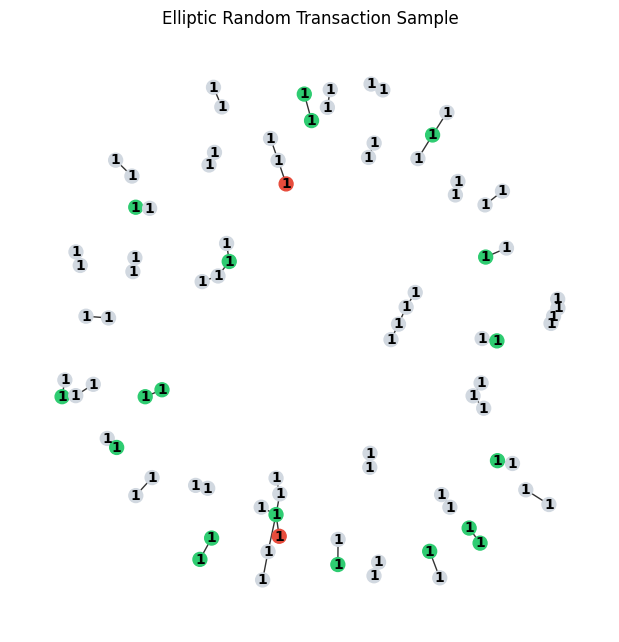

In [ ]:
# plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, k=0.1, iterations=30) # Reduced iterations for MVP speed
# nx.draw(G, pos, node_color=colors, node_size=20, edge_color="#080808",)# alpha=0.7)
# plt.title("Elliptic Transactions Sample")
# plt.show()

plt.figure(figsize=(6,6))
# Use circular_layout for 10 nodes; it's much clearer for small samples
#pos = nx.circular_layout(G) 
nx.draw(G, pos, node_color=colors, node_size=100, edge_color="#333", with_labels=False)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color="black", font_weight="bold")
plt.title("Elliptic Random Transaction Sample from time-step 1")
plt.show()